In [38]:
import os
import re
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from pathlib import Path

synthea_path   = "csv"
text_data_path = "notes"
output_path    = "output"
CHUNK_SIZE     = 50_000

NOTES_FILES = list(Path(text_data_path).glob("*.txt"))
os.makedirs(output_path, exist_ok=True)

In [2]:
ENC_COLS  = ['Id', 'PATIENT', 'ENCOUNTERCLASS', 'START', 'STOP', 'REASONCODE', 'REASONDESCRIPTION']
PAT_COLS  = ['Id', 'GENDER', 'RACE', 'ETHNICITY', 'MARITAL', 'BIRTHDATE']
OBS_COLS  = ['PATIENT', 'ENCOUNTER', 'DATE', 'CODE', 'DESCRIPTION', 'VALUE', 'UNITS']
COND_COLS = ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION']
MED_COLS  = ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'REASONCODE', 'REASONDESCRIPTION']

enc_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/encounters.csv", usecols=ENC_COLS, chunksize=CHUNK_SIZE):
    enc_chunks.append(chunk[chunk['ENCOUNTERCLASS'] == 'inpatient'])
encounters_df = pd.concat(enc_chunks, ignore_index=True)
del enc_chunks
print(f"Inpatient encounters: {len(encounters_df)}")

encounters_df = encounters_df.rename(columns={
    'Id':                'hadm_id',
    'PATIENT':           'subject_id',
    'ENCOUNTERCLASS':    'admission_type',
    'START':             'admittime',
    'STOP':              'dischtime',
    'REASONCODE':        'reason_code',
    'REASONDESCRIPTION': 'reason_description',
})

inpatient_subject_ids = set(encounters_df['subject_id'])

Inpatient encounters: 110841


In [3]:
pat_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/patients.csv", usecols=PAT_COLS, chunksize=CHUNK_SIZE):
    pat_chunks.append(chunk[chunk['Id'].isin(inpatient_subject_ids)])
patients_df = pd.concat(pat_chunks, ignore_index=True).rename(columns={
    'Id':        'subject_id',
    'GENDER':    'gender',
    'RACE':      'race',
    'ETHNICITY': 'ethnicity',
    'MARITAL':   'marital_status',
    'BIRTHDATE': 'birthdate',
})
del pat_chunks

In [4]:
df_phy_ad = encounters_df.merge(patients_df, on='subject_id', how='left')
del encounters_df, patients_df

for col in ('admittime', 'dischtime', 'birthdate'):
    df_phy_ad[col] = pd.to_datetime(df_phy_ad[col], errors='coerce').dt.tz_localize(None)

df_phy_ad = df_phy_ad.dropna(subset=['admittime', 'dischtime']).copy()
df_phy_ad['LOS']        = (df_phy_ad['dischtime'] - df_phy_ad['admittime']).dt.days
df_phy_ad['anchor_age'] = (df_phy_ad['admittime'] - df_phy_ad['birthdate']).dt.days // 365

df_phy_ad = df_phy_ad[(df_phy_ad['LOS'] > 0) & (df_phy_ad['LOS'] <= 500)].copy()
print(f"After LOS sanity filter: {len(df_phy_ad)} encounters")

los_mean      = df_phy_ad['LOS'].mean()
los_std       = df_phy_ad['LOS'].std(ddof=0)
los_threshold = los_mean + 2 * los_std
print(f"LOS mean: {los_mean:.2f}  std: {los_std:.2f}  LLOS threshold: {los_threshold:.2f} days")

After LOS sanity filter: 110841 encounters
LOS mean: 4.51  std: 4.73  LLOS threshold: 13.98 days


In [5]:
n_before = len(df_phy_ad)

df_phy_ad = df_phy_ad[df_phy_ad['LOS'] > los_threshold].copy()

print(f"LLOS cohort: {len(df_phy_ad)} / {n_before} encounters ({len(df_phy_ad)/n_before*100:.1f}%)")

cohort_hadm_ids = set(df_phy_ad['hadm_id'])
cohort_subj_ids = set(df_phy_ad['subject_id'])
print(f"Cohort: {len(cohort_hadm_ids)} LLOS encounters across {len(cohort_subj_ids)} patients")

LLOS cohort: 5026 / 110841 encounters (4.5%)
Cohort: 5026 LLOS encounters across 3830 patients


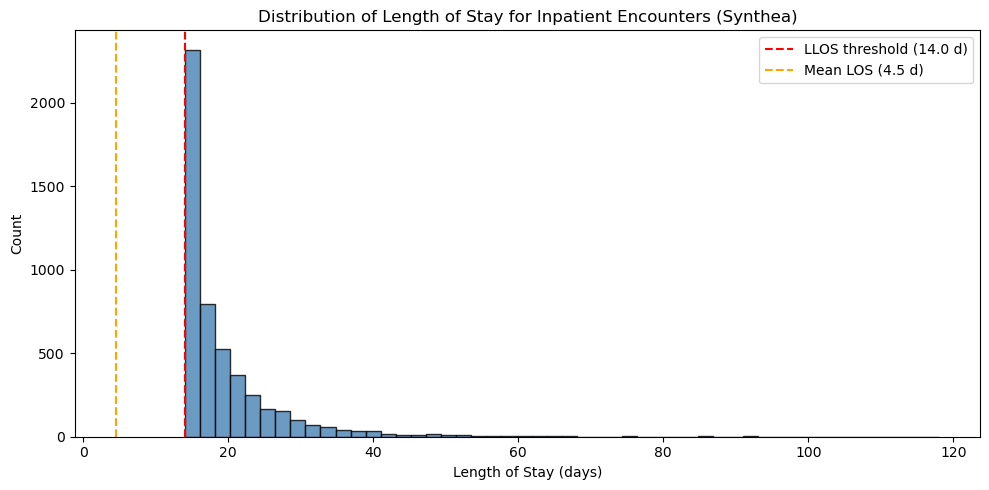

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_phy_ad['LOS'], bins=50, edgecolor='black', color='steelblue', alpha=0.8)
ax.axvline(los_threshold, color='red',    linestyle='--', linewidth=1.5,
           label=f'LLOS threshold ({los_threshold:.1f} d)')
ax.axvline(los_mean,      color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean LOS ({los_mean:.1f} d)')
ax.set_xlabel('Length of Stay (days)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Length of Stay for Inpatient Encounters (Synthea)')
ax.legend()
plt.tight_layout()
fig.savefig(f"{output_path}/los_histogram.png", dpi=150)
plt.show()

In [7]:
obs_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/observations.csv", usecols=OBS_COLS, chunksize=CHUNK_SIZE):
    obs_chunks.append(chunk[chunk['ENCOUNTER'].isin(cohort_hadm_ids)])
observations_df = pd.concat(obs_chunks, ignore_index=True).rename(columns={
    'PATIENT':     'subject_id',
    'ENCOUNTER':   'hadm_id',
    'DATE':        'obs_date',
    'CODE':        'obs_code',
    'DESCRIPTION': 'obs_description',
    'VALUE':       'obs_value',
    'UNITS':       'obs_units',
})
del obs_chunks

In [8]:
observations_df['obs_date'] = pd.to_datetime(
    observations_df['obs_date'], errors='coerce'
).dt.tz_localize(None)
observations_df['obs_description_lower'] = observations_df['obs_description'].str.lower()
print(f"Observations loaded: {len(observations_df)}")

Observations loaded: 579390


In [9]:
CONDITION_SKIP_PATTERNS = [
    "medication review due",
    "full-time employment",
    "part-time employment",
    "not in labor force",
    "unemployed",
    "received higher education",
    "educated to high school level",
    "only received primary school education",
    "serving in military service",
    "refugee",
    "social migrant",
    "has a criminal record",
    "risk activity involvement",
    "gingivitis",
    "gingival disease",
    "primary dental caries",
    "loose dental filling",
    "leaking dental filling",
    "fractured dental filling",
    "dental filling lost",
    "impacted molars",
    "alveolitis of jaw",
    "infection of tooth",
    "loss of teeth",
    "torus palatinus",
    "torus mandibularis",
    "resorption of alveolar process",
    "normal pregnancy",
    "past pregnancy history of miscarriage",
    "miscarriage in first trimester",
    "miscarriage in second trimester",
    "complete miscarriage",
    "blighted ovum",
    "tubal pregnancy",
    "eclampsia in pregnancy",
    "pre-eclampsia",
    "high risk pregnancy",
    "congenital uterine anomaly",
    "history of tubal ligation",
    "sterilization requested",
    "fetus with chromosomal abnormality",
    "complication occurring during pregnancy",
    "suspected disease caused by severe acute respiratory coronavirus 2",
    "social isolation",
    "limited social contact",
    "housing unsatisfactory",
    "lack of access to transportation",
    "transport problem",
    "victim of intimate partner abuse",
    "reports of violence in the environment",
    "homeless",
    "tongue tie",
]

SNOMED_SUFFIX = re.compile(r"\s*\([^)]+\)\s*$")

In [10]:
def _should_skip_condition(desc: str) -> bool:
    lower = desc.lower()
    return any(lower.startswith(pat) or pat in lower for pat in CONDITION_SKIP_PATTERNS)

def _clean_condition(desc: str) -> str:
    return SNOMED_SUFFIX.sub("", str(desc)).strip()

In [11]:
cond_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/conditions.csv", usecols=COND_COLS, chunksize=CHUNK_SIZE):

    chunk["START"] = pd.to_datetime(chunk["START"], errors="coerce").dt.tz_localize(None)
    chunk["STOP"]  = pd.to_datetime(chunk["STOP"],  errors="coerce")

    chunk["CONDITION_STATUS"] = chunk["STOP"].apply(
        lambda x: "ongoing" if pd.isna(x) else "resolved"
    )

    filtered = chunk[
        chunk["PATIENT"].isin(cohort_subj_ids) &
        (chunk["CONDITION_STATUS"] == "ongoing") &
        (~chunk["DESCRIPTION"].apply(_should_skip_condition))
    ].copy()
    cond_chunks.append(filtered)

conditions_df = pd.concat(cond_chunks, ignore_index=True).rename(columns={
    "START":            "cond_start",
    "PATIENT":          "subject_id",
    "ENCOUNTER":        "cond_encounter",
    "CODE":             "snomed_code",
    "DESCRIPTION":      "cond_description",
    "CONDITION_STATUS": "cond_status",
})

In [12]:
del cond_chunks
conditions_df['cond_start'] = pd.to_datetime(
    conditions_df['cond_start'], errors='coerce'
)
conditions_df['cond_clean'] = conditions_df['cond_description'].apply(_clean_condition)

print(f"Ongoing conditions loaded: {len(conditions_df)}")
print(f"Unique condition types: {conditions_df['cond_description'].nunique()}")

Ongoing conditions loaded: 39737
Unique condition types: 211


In [13]:
med_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/medications.csv", usecols=MED_COLS, chunksize=CHUNK_SIZE):
    chunk["START"] = pd.to_datetime(chunk["START"], errors="coerce").dt.tz_localize(None)
    chunk["STOP"]  = pd.to_datetime(chunk["STOP"],  errors="coerce")

    chunk["MEDICATION_STATUS"] = chunk["STOP"].apply(
        lambda x: "ongoing" if pd.isna(x) else "stopped"
    )
    chunk["REASONCODE"]        = chunk["REASONCODE"].fillna("not reported")
    chunk["REASONDESCRIPTION"] = chunk["REASONDESCRIPTION"].fillna("not reported")

    filtered = chunk[
        chunk["PATIENT"].isin(cohort_subj_ids) &
        (chunk["MEDICATION_STATUS"] == "ongoing")
    ].copy()
    med_chunks.append(filtered)

In [14]:
medications_df = pd.concat(med_chunks, ignore_index=True).rename(columns={
    'START':             'med_start',
    'STOP':              'med_stop',
    'PATIENT':           'subject_id',
    'ENCOUNTER':         'med_encounter',
    'CODE':              'med_code',
    'DESCRIPTION':       'med_description',
    'REASONCODE':        'med_reason_code',
    'REASONDESCRIPTION': 'med_reason_description',
    'MEDICATION_STATUS': 'med_status',
})
del med_chunks
print(f"Active medications loaded: {len(medications_df)}")

Active medications loaded: 16594


In [15]:
obs_with_admit = observations_df.merge(
    df_phy_ad[['hadm_id', 'admittime']], on='hadm_id', how='inner'
)
obs_12h = obs_with_admit[
    (obs_with_admit['obs_date'] >= obs_with_admit['admittime']) &
    (obs_with_admit['obs_date'] <= obs_with_admit['admittime'] + pd.Timedelta(hours=12))
].copy()

VITAL_MAP = {
    'heart rate':               'Heart rate: {} bpm',
    'systolic blood pressure':  'Systolic BP: {} mmHg',
    'diastolic blood pressure': 'Diastolic BP: {} mmHg',
    'respiratory rate':         'Respiratory rate: {} /min',
    'body weight':              'Weight: {} kg',
    'body height':              'Height: {} cm',
    'body mass index':          'BMI: {}',
}

In [16]:
def _label_vital(desc_lower: pd.Series) -> pd.Series:
    label = pd.Series('', index=desc_lower.index)
    for keyword in VITAL_MAP:
        label[desc_lower.str.contains(keyword, na=False)] = keyword
    return label

obs_12h['vital_key'] = _label_vital(obs_12h['obs_description_lower'])
vitals_only = obs_12h[obs_12h['vital_key'] != ''].copy()
vitals_only['vital_str'] = vitals_only.apply(
    lambda r: VITAL_MAP[r['vital_key']].format(r['obs_value']), axis=1
)
vitals_agg = (
    vitals_only.groupby('hadm_id')['vital_str']
    .apply('; '.join)
    .reset_index()
    .rename(columns={'vital_str': 'vitals_text'})
)
del obs_12h, vitals_only

In [17]:
SKIP_LAB_PATTERNS = ['systolic', 'diastolic', 'heart rate', 'respiratory', 'body']
obs_2h = obs_with_admit[
    (obs_with_admit['obs_date'] >= obs_with_admit['admittime']) &
    (obs_with_admit['obs_date'] <= obs_with_admit['admittime'] + pd.Timedelta(hours=2))
].copy()
del obs_with_admit

skip_mask = obs_2h['obs_description_lower'].str.contains(
    '|'.join(SKIP_LAB_PATTERNS), na=False
)
labs_only = obs_2h[~skip_mask].copy()
del obs_2h, observations_df

_PAIN_PAT   = re.compile(r"(?i)^pain severity")
_DESC_NOISE = re.compile(r"\s*-\s*(reported|\[.*?\])\s*$", re.IGNORECASE)
_JUNK_UNIT  = re.compile(r"^\{.*\}$")

In [18]:
_RE_BRACKET  = re.compile(r'\s*\[.*?\]\s*')
_RE_IN_SPEC  = re.compile(
    r'\s+(?:in|of)\s+(?:serum\s+or\s+plasma|blood(?:\s+by\s+.*)?|'
    r'urine(?:\s+by\s+.*)?|serum(?:\s+.*)?|plasma(?:\s+.*)?)'
    r'(?:\s+by\s+.*)?$', re.IGNORECASE
)
_RE_BY_METH  = re.compile(r'\s+by\s+.*$', re.IGNORECASE)
_RE_SPACES   = re.compile(r'\s{2,}')
_RE_URINE    = re.compile(r'\bin\s+urine\b', re.IGNORECASE)
_RE_GFR      = re.compile(r'glomerular filtration rate', re.IGNORECASE)
_RE_GFR_METH = re.compile(r'by\s+creatinine-based\s+formula\s*\(([^)]+)\)', re.IGNORECASE)

def _auto_lab_name(desc: str) -> str:
    raw  = str(desc).strip()
    norm = raw.lower()
    if norm.startswith('pain severity'):
        return 'Pain score (0-10)'
    is_urine = bool(_RE_URINE.search(norm))
    if _RE_GFR.search(norm):
        m = _RE_GFR_METH.search(norm)
        return f"GFR ({m.group(1).upper()})" if m else "GFR"
    name = _RE_BRACKET.sub(' ', raw)
    name = _RE_IN_SPEC.sub('', name)
    name = _RE_BY_METH.sub('', name)
    name = _RE_SPACES.sub(' ', name).strip().title()
    if is_urine and not name.lower().startswith('urine'):
        name = f'Urine {name}'
    return name if name else raw.strip()

def _clean_lab_desc(desc: str) -> str:
    return _auto_lab_name(desc)

def _clean_lab_unit(unit) -> str:
    if pd.isna(unit):
        return ""
    unit = str(unit).strip()
    return "" if _JUNK_UNIT.match(unit) else unit

labs_only["obs_description_clean"] = labs_only["obs_description"].apply(_clean_lab_desc)
labs_only["obs_units_clean"]       = labs_only["obs_units"].apply(_clean_lab_unit)
labs_only["lab_str"] = (
    labs_only["obs_description_clean"] + ": " + labs_only["obs_value"].astype(str)
)
has_units = labs_only["obs_units_clean"] != ""
labs_only.loc[has_units, "lab_str"] += " " + labs_only.loc[has_units, "obs_units_clean"]
labs_only = labs_only.groupby('hadm_id').head(10)
labs_agg = (
    labs_only.groupby('hadm_id')['lab_str']
    .apply('; '.join)
    .reset_index()
    .rename(columns={'lab_str': 'labs_text'})
)
del labs_only

In [19]:
cond_with_admit = conditions_df.merge(
    df_phy_ad[['subject_id', 'hadm_id', 'admittime']], on='subject_id', how='inner'
)
del conditions_df

cond_at_admit = cond_with_admit[
    cond_with_admit['cond_start'] <= cond_with_admit['admittime']
].copy()
del cond_with_admit

MAX_COND_ONGOING = 10

def _agg_conditions(group, max_items):
    seen = []
    for desc in group:
        if desc not in seen:
            seen.append(desc)
        if len(seen) >= max_items:
            break
    return "; ".join(seen) if seen else ""

ongoing_agg = (
    cond_at_admit
    .groupby('hadm_id')['cond_clean']
    .apply(lambda g: _agg_conditions(g, MAX_COND_ONGOING))
    .reset_index()
    .rename(columns={'cond_clean': 'conditions_ongoing_text'})
)
print(f"Encounters with ongoing conditions: {len(ongoing_agg)}")

snomed_dummies = (
    cond_at_admit[['hadm_id', 'snomed_code']]
    .drop_duplicates()
    .assign(flag=1)
    .pivot_table(index='hadm_id', columns='snomed_code', values='flag', fill_value=0)
)
snomed_dummies.columns = [f"snomed_{c}" for c in snomed_dummies.columns]
snomed_dummies = snomed_dummies.reset_index()
print(f"SNOMED multi-hot: {snomed_dummies.shape[0]} encounters x {snomed_dummies.shape[1]-1} codes")

del cond_at_admit

Encounters with ongoing conditions: 4988
SNOMED multi-hot: 4988 encounters x 158 codes


In [20]:
MAX_MEDS = 10

med_with_admit = medications_df.merge(
    df_phy_ad[['subject_id', 'hadm_id', 'admittime']], on='subject_id', how='inner'
)
del medications_df

med_pre_admit = med_with_admit[
    med_with_admit['med_start'] < med_with_admit['admittime']
].copy()
del med_with_admit

med_pre_admit = (
    med_pre_admit
    .sort_values('med_start')
    .drop_duplicates(subset=['hadm_id', 'med_description'], keep='first')
)

med_pre_admit['med_str'] = med_pre_admit['med_description']

meds_agg = (
    med_pre_admit.groupby('hadm_id')['med_str']
    .apply(lambda g: "; ".join(g.head(MAX_MEDS)))
    .reset_index()
    .rename(columns={'med_str': 'medications_text'})
)
del med_pre_admit
print(f"Encounters with active pre-admission medications: {len(meds_agg)}")

Encounters with active pre-admission medications: 2894


In [21]:
df_phy_ad['admission_type_text'] = df_phy_ad['admission_type']

df_phy_ad['admit_date'] = df_phy_ad['admittime'].dt.date
df_phy_ad['admit_time'] = df_phy_ad['admittime'].dt.time

df_phy_ad['disch_date'] = df_phy_ad['dischtime'].dt.date
df_phy_ad['disch_time'] = df_phy_ad['dischtime'].dt.time

df_phy_ad = (
    df_phy_ad
    .merge(vitals_agg,  on='hadm_id', how='left')
    .merge(labs_agg,    on='hadm_id', how='left')
    .merge(ongoing_agg, on='hadm_id', how='left')
    .merge(meds_agg,    on='hadm_id', how='left')
)
del vitals_agg, labs_agg, ongoing_agg, meds_agg

In [22]:
DATE_LINE              = re.compile(r"^\d{4}-\d{2}-\d{2}\s*$")
SNOMED_TAG_END         = re.compile(r"\s*\([^)]+\)\s*$")
SNOMED_TAG_ALL         = re.compile(r"\s*\([^)]+\)")
SECTION_HEADER_CLEANER = re.compile(
    r"(?i)^(history of present illness|hpi|social history|"
    r"chief complaint|medications)\s*[-:]*\s*"
)

SECTION_TAGS = {
    "history of present illness": "hpi",
    "hpi":                        "hpi",
    "social history":             "social_history",
    "chief complaint":            "chief_complaint",
    "medications":                "medications",
}

_SNOMED_INLINE_SECTIONS = {"hpi"}
_PERIOD_SECTIONS        = {"hpi"}

_SKIP_SECTIONS          = {"allergies", "general", "assessment_and_plan", "assessment and plan", "plan", "medications"}
_SECTION_ORDER          = ["hpi", "social_history", "chief_complaint"]

In [23]:
def split_into_notes(text: str) -> list[str]:
    if pd.isna(text):
        return []
    parts = re.split(r"(?=^\d{4}-\d{2}-\d{2}\s*$)", text, flags=re.MULTILINE)
    return [p.strip() for p in parts if p.strip()]

def extract_date_from_note(note: str):
    first_line = note.split("\n")[0].strip()
    return pd.Timestamp(first_line).date() if DATE_LINE.match(first_line) else None

def _ensure_period(text: str) -> str:
    text = text.strip()
    return text if not text or text[-1] in ".!?" else text + "."

In [24]:
def clean_note_to_sections(text: str) -> OrderedDict:
    sections: OrderedDict = OrderedDict()
    current_section = "general"

    def add(section, value):
        value = re.sub(r"\s+", " ", value).strip()
        if value:
            sections.setdefault(section, []).append(value)

    for line in text.split("\n"):
        line = line.strip()
        if not line:
            continue
        line = line.replace("#", "").strip()
        if current_section in _SNOMED_INLINE_SECTIONS:
            line = SNOMED_TAG_ALL.sub("", line).strip()
        else:
            line = SNOMED_TAG_END.sub("", line).strip()
        if not line:
            continue
        lower = line.lower()

        matched_tag    = next((v for k, v in SECTION_TAGS.items() if lower.startswith(k)), None)
        is_skip_header = any(lower.startswith(k) for k in (
            "assessment and plan", "assessment", "plan", "allergies"
        ))

        if is_skip_header:
            current_section = "assessment_and_plan"
            continue

        if matched_tag:
            current_section = matched_tag
            line = SECTION_HEADER_CLEANER.sub("", line).strip()
            line = re.sub(
                rf"(?i)^{re.escape(matched_tag.replace('_', ' '))}\s*[-:]?\s*", "", line
            ).strip()
            if current_section in _SNOMED_INLINE_SECTIONS:
                line = SNOMED_TAG_ALL.sub("", line).strip()
            add(current_section, line)
        else:
            if current_section in _SKIP_SECTIONS:
                continue
            add(current_section, line)

    raw: dict = {}
    for section, items in sections.items():
        if section in _SKIP_SECTIONS:
            continue
        if section in ("hpi", "medications"):
            raw[section] = _ensure_period(" ".join(items).strip())
        else:
            seen, cleaned = set(), []
            for item in items:
                item = item.strip()
                if item and item not in seen:
                    seen.add(item)
                    cleaned.append(item)
            raw[section] = " ".join(cleaned).strip()

    final: OrderedDict = OrderedDict()
    for section in _SECTION_ORDER:
        if section in raw and raw[section]:
            final[section] = raw[section]
    for section, value in raw.items():
        if section not in final and value:
            final[section] = value
    return final

In [25]:
def serialize_sections(section_dict: OrderedDict) -> str:
    parts = []
    for section, value in section_dict.items():
        if value:
            text = _ensure_period(value) if section in _PERIOD_SECTIONS else value
            parts.append(f"<{section}> {text}")
    return " </s> ".join(parts)

def clean_for_t5(text: str) -> str:
    return serialize_sections(clean_note_to_sections(text))

In [26]:
df_phy_ad['admit_date'] = df_phy_ad['admittime'].dt.date
df_phy_ad['disch_date'] = df_phy_ad['dischtime'].dt.date

_admit_lookup: dict[str, set] = (
    df_phy_ad.groupby('subject_id')['admit_date'].apply(set).to_dict()
)

raw_note_rows: list[dict] = []
for fp in NOTES_FILES:
    patient_id = fp.stem.split('_')[-1]
    if patient_id not in cohort_subj_ids:      
        continue
    admit_dates = _admit_lookup.get(patient_id)
    if not admit_dates:
        continue
    text = fp.read_text(encoding='utf-8')
    for note in split_into_notes(text):
        dt = extract_date_from_note(note)
        if dt is not None and dt in admit_dates:
            raw_note_rows.append({
                'subject_id': patient_id,
                'note_date':  dt,
                'note_text':  note,
            })

notes_df = pd.DataFrame(raw_note_rows)
del raw_note_rows
print(f"Raw note segments matching cohort: {len(notes_df)}")
if notes_df.empty:
    print("No matching notes found")
    raise SystemExit

Raw note segments matching cohort: 5772


In [27]:
notes_df = notes_df.drop_duplicates(subset=['subject_id', 'note_date', 'note_text'], keep='first')
notes_df = notes_df.drop_duplicates(subset=['subject_id', 'note_text'], keep='first')
print(f"After deduplication: {len(notes_df)} note segments")

After deduplication: 5771 note segments


In [28]:
unique_texts = notes_df['note_text'].unique()
text_to_sections = {t: clean_note_to_sections(t) for t in unique_texts}
notes_df['sections'] = notes_df['note_text'].map(text_to_sections)
del text_to_sections

NOTE_SECTION_COLS = ['hpi', 'social_history', 'chief_complaint']

_HPI_DEMO_PAT = re.compile(
    r'^(?:\S+\s+)+is\s+a\s+\d+\s+year[- ]old\s+'
    r'(?:non)?(?:hispanic|nonhispanic)?\s*'
    r'(?:white|black|asian|latino|hispanic|african\s*american|'
    r'native\s*(?:american|hawaiian|alaskan)?|other)?\s*'
    r'(?:male|female|nonbinary|non-binary)?[.,]?\s*',
    re.IGNORECASE
)

def _strip_hpi_demo(text: str) -> str:
    if not text:
        return text
    return _HPI_DEMO_PAT.sub('', text).strip()

for col in NOTE_SECTION_COLS:
    notes_df[col] = notes_df['sections'].apply(lambda d: d.get(col, '') if isinstance(d, dict) else '')

notes_df['hpi'] = notes_df['hpi'].apply(_strip_hpi_demo)

notes_df = notes_df[notes_df[NOTE_SECTION_COLS].apply(
    lambda row: any(v.strip() for v in row), axis=1
)]

notes_agg = (
    notes_df
    .groupby(['subject_id', 'note_date'])[NOTE_SECTION_COLS]
    .agg(lambda x: ' | '.join(v for v in x.drop_duplicates() if v.strip()))
    .reset_index()
)
del notes_df

cohort_slim = df_phy_ad[[
    'subject_id', 'hadm_id',
    'admit_date', 'admit_time', 'disch_date', 'disch_time', 'LOS',
    'vitals_text', 'labs_text', 'conditions_ongoing_text', 'medications_text',
    'admission_type_text',
]].copy()

In [29]:
merged = cohort_slim.merge(notes_agg, on='subject_id', how='inner')
del notes_agg
merged = merged[
    (merged['note_date'] >= merged['admit_date']) &
    (merged['note_date'] <= merged['disch_date'])
]

NOTE_SECTION_COLS = ['hpi', 'social_history', 'chief_complaint']

enc_notes = (
    merged
    .groupby('hadm_id')[NOTE_SECTION_COLS]
    .agg(lambda x: ' | '.join(v for v in x.drop_duplicates() if v.strip()))
    .reset_index()
)
del merged

feat_cols = [
    'hadm_id', 'vitals_text', 'labs_text', 'conditions_ongoing_text', 'medications_text',
    'admission_type_text',
    'admit_date', 'admit_time', 'disch_date', 'disch_time',
]
feat_df = cohort_slim[feat_cols].drop_duplicates('hadm_id').copy()

In [30]:
dataset = cohort_slim[['subject_id', 'hadm_id', 'LOS']].merge(enc_notes, on='hadm_id', how='inner')
del enc_notes

feat_df = feat_df.rename(columns={
    'vitals_text':             'vitals',
    'labs_text':               'labs',
    'conditions_ongoing_text': 'conditions',
    'medications_text':        'medications',
    'admission_type_text':     'admission_type',
})

dataset = dataset.merge(feat_df, on='hadm_id', how='left')
del feat_df

In [31]:
dataset = dataset.rename(columns={'LOS': 'target'})
dataset = dataset[dataset['hadm_id'].isin(cohort_hadm_ids)].copy()

valid_subjects = set(dataset['subject_id'])
print(f"Final LLOS encounters: {len(dataset)}  |  Patients with >=1 LLOS encounter: {len(valid_subjects)}")

dataset_full = dataset.merge(
    df_phy_ad[[
        'subject_id', 'hadm_id',
        'anchor_age', 'gender', 'race', 'ethnicity', 'birthdate', 'admission_type',
    ]],
    on=['subject_id', 'hadm_id'],
    how='left',
    suffixes=('', '_raw'),
)
if 'admission_type_raw' in dataset_full.columns:
    dataset_full = dataset_full.drop(columns=['admission_type_raw'])

del dataset, cohort_slim

dataset_full = dataset_full.merge(snomed_dummies, on='hadm_id', how='left')
del snomed_dummies
snomed_cols = [c for c in dataset_full.columns if c.startswith('snomed_')]
dataset_full[snomed_cols] = dataset_full[snomed_cols].fillna(0).astype('int8')
print(f"SNOMED feature columns: {len(snomed_cols)}")

id_cols    = ['subject_id', 'hadm_id']
demo_cols  = ['gender', 'race', 'ethnicity', 'anchor_age', 'birthdate']
time_cols  = ['admit_date', 'admit_time', 'disch_date', 'disch_time', 'admission_type']
text_cols  = ['hpi', 'social_history', 'chief_complaint', 'vitals', 'labs', 'conditions', 'medications']
target     = ['target']

ordered_cols = id_cols + demo_cols + time_cols + text_cols + snomed_cols + target
dataset_full = dataset_full[[c for c in ordered_cols if c in dataset_full.columns]]

dataset_full.to_csv(f"{output_path}/Dataset_Tabular.csv", index=False)
print(f"Saved to {output_path}/Dataset_Tabular.csv")

Final LLOS encounters: 5026  |  Patients with >=1 LLOS encounter: 3830
SNOMED feature columns: 158
Saved to output/Dataset_Tabular.csv


In [32]:
print(f"\nFinal dataset shape:  {dataset_full.shape}")
print(f"Columns:              {list(dataset_full.columns)}")
print(f"Unique patients:      {dataset_full['subject_id'].nunique()}")
print(f"Total encounters:     {len(dataset_full)}")
print(f"Admission types:      {dataset_full['admission_type'].value_counts().to_dict()}")
print(f"HPI coverage:         {(dataset_full['hpi'].str.strip() != '').sum()} / {len(dataset_full)}")
print(f"Social Hx coverage:   {(dataset_full['social_history'].str.strip() != '').sum()} / {len(dataset_full)}")
print(f"Chief complaint cov.: {(dataset_full['chief_complaint'].str.strip() != '').sum()} / {len(dataset_full)}")


Final dataset shape:  (5026, 178)
Columns:              ['subject_id', 'hadm_id', 'gender', 'race', 'ethnicity', 'anchor_age', 'birthdate', 'admit_date', 'admit_time', 'disch_date', 'disch_time', 'admission_type', 'hpi', 'social_history', 'chief_complaint', 'vitals', 'labs', 'conditions', 'medications', 'snomed_4557003', 'snomed_5602001', 'snomed_6072007', 'snomed_6525002', 'snomed_7200002', 'snomed_15802004', 'snomed_22253000', 'snomed_24079001', 'snomed_26929004', 'snomed_27942005', 'snomed_36955009', 'snomed_39898005', 'snomed_40055000', 'snomed_44054006', 'snomed_44465007', 'snomed_46177005', 'snomed_47505003', 'snomed_48724000', 'snomed_49436004', 'snomed_49727002', 'snomed_49915006', 'snomed_53827007', 'snomed_55822004', 'snomed_56786000', 'snomed_59621000', 'snomed_60234000', 'snomed_60573004', 'snomed_61977001', 'snomed_62106007', 'snomed_64859006', 'snomed_67782005', 'snomed_68496003', 'snomed_68566005', 'snomed_69896004', 'snomed_73430006', 'snomed_73595000', 'snomed_7657100

In [33]:
print(dataset_full['hpi'].iloc[51][:500])

Patient has a history of medication review due, viral sinusitis, otitis media, suspected disease caused by severe acute respiratory coronavirus 2.


In [34]:
dataset_full.head()

,subject_id,hadm_id,gender,race,ethnicity,anchor_age,birthdate,admit_date,admit_time,disch_date,...,snomed_97331000119101,snomed_108631000119101,snomed_119481000119105,snomed_124171000119105,snomed_152621000119105,snomed_153351000119102,snomed_157141000119108,snomed_368581000119106,snomed_10939881000119105,target
0,47d390c6-a1a2-1a80-dd1d-9722c7b24159,47d390c6-a1a2-1a80-6443-22f99dbbb226,M,white,nonhispanic,12,2008-08-05,2021-01-25,19:49:23,2021-02-08,...,0,0,0,0,0,0,0,0,0,14
1,5e7ebf2c-22ec-a89b-53ab-38edddd81be9,5e7ebf2c-22ec-a89b-8fc8-b8b76ca29724,F,white,nonhispanic,43,1973-01-03,2016-08-31,11:30:43,2016-09-17,...,0,0,0,1,0,0,0,0,0,17
2,e205f296-2f9b-ca58-f00a-86cc785ad935,e205f296-2f9b-ca58-f5a9-a821b301cd8b,M,white,nonhispanic,55,1964-12-06,2019-12-20,02:20:06,2020-01-10,...,0,0,0,1,0,0,0,0,0,21
3,e205f296-2f9b-ca58-f00a-86cc785ad935,e205f296-2f9b-ca58-14c8-fadef3db5532,M,white,nonhispanic,60,1964-12-06,2024-11-29,02:25:16,2024-12-13,...,0,0,0,1,0,0,0,0,0,14
4,76a1559f-a83a-59b9-ed07-4efd4a0f1b39,76a1559f-a83a-59b9-c245-802016ebe25f,F,white,nonhispanic,34,1982-12-13,2017-01-28,09:30:42,2017-02-11,...,0,0,0,1,0,0,0,0,0,14


In [35]:
dataset_full.dtypes

subject_id                  object
hadm_id                     object
gender                      object
race                        object
ethnicity                   object
                             ...  
snomed_153351000119102        int8
snomed_157141000119108        int8
snomed_368581000119106        int8
snomed_10939881000119105      int8
target                       int64
Length: 178, dtype: object

In [41]:
Xdf = dataset_full["target"].to_frame()

In [42]:
summary_stats = Xdf.describe().T
summary_stats["skew"] = Xdf.skew()
summary_stats["kurtosis"] = Xdf.kurtosis()

summary_stats

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
target,5026.0,19.481098,7.920459,14.0,15.0,17.0,21.0,118.0,3.737255,23.111169
